In [1]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.checkpoint import checkpoint

In [5]:
data_train_dir='train'
data_test_dir='val'
data_train_dir2='train_2'
data_test_dir2='val_2'

In [6]:
print(os.listdir(data_train_dir))
num_classes=len(os.listdir(data_train_dir))

print(os.listdir(data_test_dir))
num_classes2=len(os.listdir(data_test_dir))

print(os.listdir(data_train_dir2))
num_classes=len(os.listdir(data_train_dir))

print(os.listdir(data_test_dir2))
num_classes2=len(os.listdir(data_test_dir))

['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
['0', '1']
['0', '1']


In [ ]:
import torch
import random
import timm
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
import torch.nn as nn
from collections import defaultdict
import numpy as np
from torch.optim.lr_scheduler import StepLR
from PIL import Image, ImageFilter

# Define the paths to the train and validation datasets
train_data_dir = 'train2'  
val_data_dir = 'val2'  

# Set the number of samples per class 
num_samples_per_class = 1100  

# Define a custom dataset to handle the undersampling
class UndersampledImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None, target_transform=None, num_samples_per_class=None):
        super().__init__(root, transform=transform, target_transform=target_transform)
        self.num_samples_per_class = num_samples_per_class

        self.samples, self.targets = self.undersample()

    def undersample(self):
        # Get the class labels 
        class_indices = defaultdict(list)
        for idx, target in enumerate(self.targets):
            class_indices[target].append(idx)

        # Subset of samples after undersampling
        selected_indices = []

        for class_idx, indices in class_indices.items():
            sampled_indices = random.sample(indices, min(self.num_samples_per_class, len(indices)))
            selected_indices.extend(sampled_indices)

        # Create the new subset of samples
        new_samples = [self.samples[idx] for idx in selected_indices]
        new_targets = [self.targets[idx] for idx in selected_indices]

        return new_samples, new_targets

# Preprocessing for training data
class CustomTransform:
    def __init__(self):
        self.transforms = transforms.Compose([
            transforms.RandomResizedCrop(224),  
            transforms.RandomHorizontalFlip(),  
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  
            transforms.RandomRotation(20),  
            transforms.RandomPerspective(distortion_scale=0.5, p=0.5, interpolation=3),  
            transforms.Lambda(self.noise_removal),  
            transforms.Lambda(self.sharpen_image),  
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
        ])

    def __call__(self, x):
        return self.transforms(x)

    def noise_removal(self, img):
        # Apply Gaussian Blur for noise removal
        return img.filter(ImageFilter.GaussianBlur(radius=1))  # Adjust the radius as needed

    def sharpen_image(self, img):
        # Apply edge sharpening using a kernel filter
        sharpness_filter = ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3)  # Adjust as needed
        return img.filter(sharpness_filter)

# Applying transformations
train_transform = CustomTransform()  # Apply custom transformations to training set
val_transform = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224 for validation
    transforms.CenterCrop(224),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load the undersampled training dataset
train_dataset = UndersampledImageFolder(root=train_data_dir, transform=train_transform, num_samples_per_class=num_samples_per_class)

# Load the validation dataset (without undersampling)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_transform)

# Split dataset
train_size = int(0.7 * len(train_dataset))  
val_size = len(train_dataset) - train_size  

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation sets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Check how many samples are left after the split
class_count = defaultdict(int)
for _, label in train_dataset:
    class_count[label] += 1

# Example of how to use the DataLoader for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained Vision Transformer model (e.g., 'vit_base_patch16_224')
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 4)  # Change the final layer for 4 classes (disease classification)
model.to(device)

# Optimizer, loss function, scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=10, gamma=0.7)

# Early Stopping parameters
early_stopping_patience = 5
best_val_loss = np.inf
epochs_without_improvement = 0

# Training loop with validation loss tracking
for epoch in range(50):  
    model.train()
    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    # Training phase
    for img, label in train_loader:
        img, label = img.to(device), label.to(device)

        optimizer.zero_grad()
        outputs = model(img)  
        loss = criterion(outputs, label)  
        loss.backward() 
        optimizer.step()  

        total_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  
        total_train_samples += label.size(0)
        total_train_correct += (predicted == label).sum().item()

    epoch_train_loss = total_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * total_train_correct / total_train_samples

    # Validation phase
    model.eval()  # Set model to evaluation mode (no gradient calculation)
    total_val_loss = 0
    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():  
        for img, label in val_loader:
            img, label = img.to(device), label.to(device)

            outputs = model(img)
            loss = criterion(outputs, label)  # Calculate validation loss

            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val_samples += label.size(0)
            total_val_correct += (predicted == label).sum().item()

    epoch_val_loss = total_val_loss / len(val_loader)
    epoch_val_accuracy = 100 * total_val_correct / total_val_samples

    # Print epoch loss and accuracy for both training and validation
    print(f"Epoch {epoch+1}/50, "
          f"Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.2f}%, "
          f"Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_accuracy:.2f}%")

    # Step the learning rate scheduler
    lr_scheduler.step()  # Update the learning rate

    # #Early stopping based on validation loss
    # if epoch_val_loss < best_val_loss:
    #     best_val_loss = epoch_val_loss
    #     epochs_without_improvement = 0
    #     # Save the best model if needed
    #     torch.save(model.state_dict(), 'best_model.pth')
    # else:
    #     epochs_without_improvement += 1

    # if epochs_without_improvement >= early_stopping_patience:
    #     print(f" Stopping training at epoch {epoch+1}.")
    #     break 


Class distribution after undersampling and splitting: {3: 767, 2: 756, 1: 783, 0: 774}
Epoch 1/50, Train Loss: 1.4825, Train Accuracy: 27.76%, Validation Loss: 1.3651, Validation Accuracy: 33.33%
Epoch 2/50, Train Loss: 1.3854, Train Accuracy: 30.42%, Validation Loss: 1.3220, Validation Accuracy: 34.77%
Epoch 3/50, Train Loss: 1.3468, Train Accuracy: 34.48%, Validation Loss: 1.3808, Validation Accuracy: 31.67%
Epoch 4/50, Train Loss: 1.2813, Train Accuracy: 37.60%, Validation Loss: 1.2582, Validation Accuracy: 42.35%
Epoch 5/50, Train Loss: 1.2319, Train Accuracy: 42.79%, Validation Loss: 1.1774, Validation Accuracy: 44.55%
Epoch 6/50, Train Loss: 1.1742, Train Accuracy: 46.01%, Validation Loss: 1.3580, Validation Accuracy: 34.32%
Epoch 7/50, Train Loss: 1.1311, Train Accuracy: 46.92%, Validation Loss: 1.1927, Validation Accuracy: 45.45%
Epoch 8/50, Train Loss: 1.1157, Train Accuracy: 47.82%, Validation Loss: 1.0667, Validation Accuracy: 51.21%
Epoch 9/50, Train Loss: 1.0727, Train Acc

Save Models

In [ ]:
torch.save(model.state_dict(), 'trained_model.pth')

Model Evaluation using Confusion Matrix and Classification Report

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set model to evaluation mode
model.load_state_dict(torch.load('trained_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad(): 
    for img, label in val_loader:
        img, label = img.to(device), label.to(device)
        outputs = model(img)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))


In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')


Precision: 0.7798
Recall: 0.7818
F1-Score: 0.7805


Testing Evaluation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
C

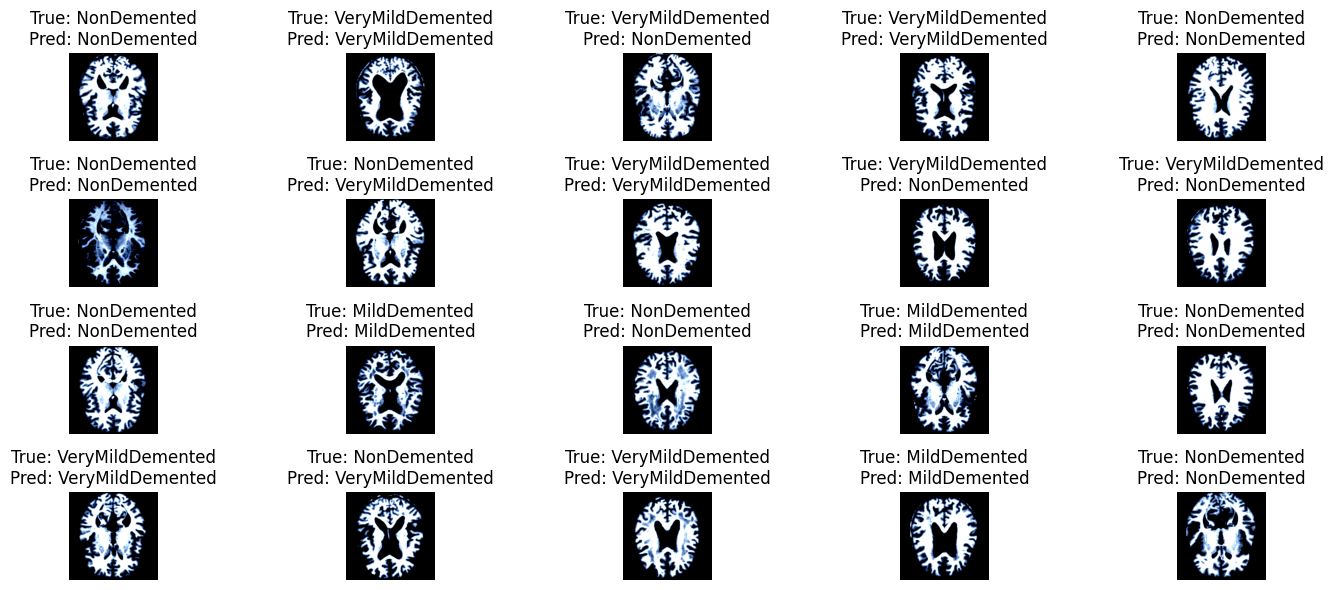

In [ ]:
test_data_dir = 'val2' 

# Define the transformations for the testing data
test_transform = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224 for testing
    transforms.CenterCrop(224),  # Center crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load testing dataset
test_dataset = datasets.ImageFolder(root=test_data_dir, transform=test_transform)

# Create a DataLoader for the testing
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)  

# Set model to evaluation mode
model.eval()

# Get a batch of testing data
data_iter = iter(test_loader)
images, labels = next(data_iter)  # Use next() instead of .next()

# Move images and labels to the device
images, labels = images.to(device), labels.to(device)

# Get predictions 
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Define the number of images
images_per_row = 5
num_images = 20  
num_rows = num_images // images_per_row

# Plot the images with their true labels and predictions
fig, axes = plt.subplots(num_rows, images_per_row, figsize=(15, 6))
axes = axes.flatten()

# Access the original test_dataset to get classes (subfolder names)
test_classes = test_dataset.classes  

for i in range(num_images):
    ax = axes[i]
    img = images[i].cpu().numpy().transpose(1, 2, 0)  # Convert to HWC format for displaying
    ax.imshow(img)
    ax.set_title(f'True: {test_classes[labels[i]]}\nPred: {test_classes[preds[i]]}')
    ax.axis('off')

plt.show()
